In [219]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll, make_moons

In [525]:
import ot

In [220]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataset

In [221]:
def get_swiss_roll(n_samples=5000):
    # Generate 3D swiss roll, but we only extract 2 dimensions to make it a 2D spiral
    data, _ = make_swiss_roll(n_samples=n_samples, noise=0.2)
    data = data[:, [0, 2]]
    # Standardize data to have zero mean and reasonable variance
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
    return torch.tensor(data, dtype=torch.float32)

In [570]:
def get_two_moons(n_samples=5000):
    data, _ = make_moons(n_samples=n_samples, noise=0.05)
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)

    # data = data*0.001;

    return torch.tensor(data, dtype=torch.float32)

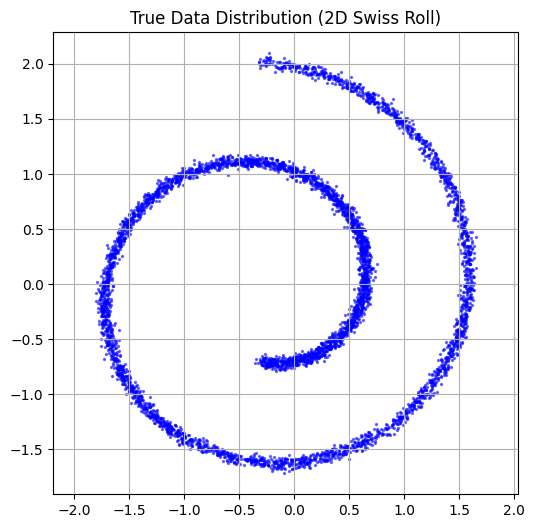

In [571]:
dataset = get_swiss_roll(5000)
# dataset = get_two_moons(5000)


plt.figure(figsize=(6, 6))
plt.scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color='blue')
plt.title("True Data Distribution (2D Swiss Roll)")
plt.axis('equal')
plt.grid(True)
plt.show()

### Score Network

In [572]:
class ScoreNetwork(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        # Input is 3-dimensional: 2D coordinate + 1D scalar sigma
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Softplus(), # Softplus ensures smooth second derivatives for score matching
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, 2) # Output is a 2D vector (the score)
        )
        
    def forward(self, x, sigma):
        # x shape: [batch_size, 2]
        # sigma shape: [batch_size, 1]
        inputs = torch.cat([x, sigma], dim=-1)
        return self.net(inputs)

## Baseline

### L = noise Levels

In [573]:
L = 10                 # Number of noise scales
sigma_1 = 1.0           # High noise (blankets the empty canvas space)
sigma_L = 0.01          # Low noise (resolves fine structure)

In [574]:
# Calculate geometric progression base gamma
def make_schedule(sigma_1, sigma_L, L):
    gamma = (sigma_L / sigma_1) ** (1.0 / (L - 1))
    return torch.tensor([sigma_1 * (gamma ** i) for i in range(L)], dtype=torch.float32)

In [575]:
sigmas = make_schedule(sigma_1, sigma_L, L)

In [576]:
print("Noise Schedule (sigmas):")
for idx, s in enumerate(sigmas):
    print(f"Level {idx+1}: {s.item():.4f}")

Noise Schedule (sigmas):
Level 1: 1.0000
Level 2: 0.5995
Level 3: 0.3594
Level 4: 0.2154
Level 5: 0.1292
Level 6: 0.0774
Level 7: 0.0464
Level 8: 0.0278
Level 9: 0.0167
Level 10: 0.0100


### Training loop

At any given noise level $i$, the perturbed data point $x_i$ is drawn from a conditional distribution:$$p(\mathbf{x}_i \mid \mathbf{x}_0) = \mathcal{N}(\mathbf{x}_i \mid \mathbf{x}_0, \sigma_i^2 \mathbf{I})$$

Because the true noise vector points away from the real data, the network's output—the Score Function $\mathbf{s}_\theta(\mathbf{x}_i, \sigma_i)$—learns to approximate the gradient of the log-density:$$\mathbf{s}_\theta(\mathbf{x}_i, \sigma_i) \approx \nabla_{\mathbf{x}_i} \log p(\mathbf{x}_i)$$

In [577]:
def train_network(sigmas):

    network = ScoreNetwork(hidden_dim=128)
    optimizer = optim.Adam(network.parameters(), lr=0.001)
    epochs = 30000
    batch_size = 128

    for epoch in range(epochs):
    # 1. Sample a clean batch of data
        idx = torch.randint(0, len(dataset), (batch_size,))
        x_clean = dataset[idx]
        
        # 2. Randomly sample an index for the noise schedule per batch item
        noise_idx = torch.randint(0, L, (batch_size,))
        sigma = sigmas[noise_idx].unsqueeze(-1) # Shape: [batch_size, 1]
        
        # 3. Sample pure Gaussian noise
        z = torch.randn_like(x_clean)
        
        # 4. Create the perturbed noisy data
        x_noisy = x_clean + sigma * z
        
        # 5. Compute true analytical score target: -z / sigma
        target_score = -z / sigma
        
        # 6. Forward pass through network
        predicted_score = network(x_noisy, sigma)
        
        # 7. Weighted MSE Loss (scaled by sigma^2 to prevent high noise from drowning out low noise)
        loss = 0.5 * torch.mean(sigma**2 * torch.sum((predicted_score - target_score) ** 2, dim=-1))
        
        # Optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 400 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f}")
    
    return network

In [578]:
network = train_network(sigmas)

Epoch [400/30000] | Loss: 152.6363
Epoch [800/30000] | Loss: 192.8336
Epoch [1200/30000] | Loss: 309.4127
Epoch [1600/30000] | Loss: 222.1806
Epoch [2000/30000] | Loss: 199.0776
Epoch [2400/30000] | Loss: 137.9444
Epoch [2800/30000] | Loss: 273.4377
Epoch [3200/30000] | Loss: 213.2321
Epoch [3600/30000] | Loss: 146.7781
Epoch [4000/30000] | Loss: 241.7280
Epoch [4400/30000] | Loss: 177.3655
Epoch [4800/30000] | Loss: 292.5297
Epoch [5200/30000] | Loss: 226.3648
Epoch [5600/30000] | Loss: 192.7581
Epoch [6000/30000] | Loss: 281.4449
Epoch [6400/30000] | Loss: 191.2341
Epoch [6800/30000] | Loss: 227.5775
Epoch [7200/30000] | Loss: 138.0220
Epoch [7600/30000] | Loss: 259.3694
Epoch [8000/30000] | Loss: 237.2164
Epoch [8400/30000] | Loss: 225.6533
Epoch [8800/30000] | Loss: 213.5315
Epoch [9200/30000] | Loss: 287.3266
Epoch [9600/30000] | Loss: 352.5663
Epoch [10000/30000] | Loss: 133.1753
Epoch [10400/30000] | Loss: 144.1437
Epoch [10800/30000] | Loss: 251.1864
Epoch [11200/30000] | Loss:

### Sample using Annealed Langevin

In [579]:
def sample_annealed_langevin(network, sigmas, n_samples=1000, T=20, eps=0.00002):
    network.eval()
    with torch.no_grad():
        # Start from a broad Gaussian distribution matching our highest noise scale
        x = torch.randn(n_samples, 2) * sigmas[0]
        
        # Outer Loop: Walk down through the noise levels from highest to lowest
        for i, sigma in enumerate(sigmas):
            # Compute step size dynamically scaled for this level
            alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
            sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
            # Inner Loop: Run Langevin Dynamics for T steps at this noise level
            for t in range(T):
                # 1. Get the score vector field from our network
                score = network(x, sigma_tensor)
                
                # 2. Add fresh noise for the random shake
                z = torch.randn_like(x)
                
                # 3. Update equation
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
                
    return x.numpy()

### visualize the evolution per noise level

In [515]:
## see how it looks for each noise level

def sample_annealed_langevin_with_tracking(network, sigmas, n_samples=1000, T=20, eps=0.00002):
    network.eval()
    trajectory = []  # List to store particle positions at each level
    
    with torch.no_grad():
        x = torch.randn(n_samples, 2) * sigmas[0]
        
        # Save initial random state (t=0)
        trajectory.append((0, x.cpu().numpy().copy()))
        
        for i, sigma in enumerate(sigmas):
            alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
            sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
            for t in range(T):
                score = network(x, sigma_tensor)
                z = torch.randn_like(x)
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
            
            # Save a snapshot after completing all T steps for this specific noise level
            trajectory.append((i + 1, x.cpu().numpy().copy()))
                
    return x.cpu().numpy(), trajectory

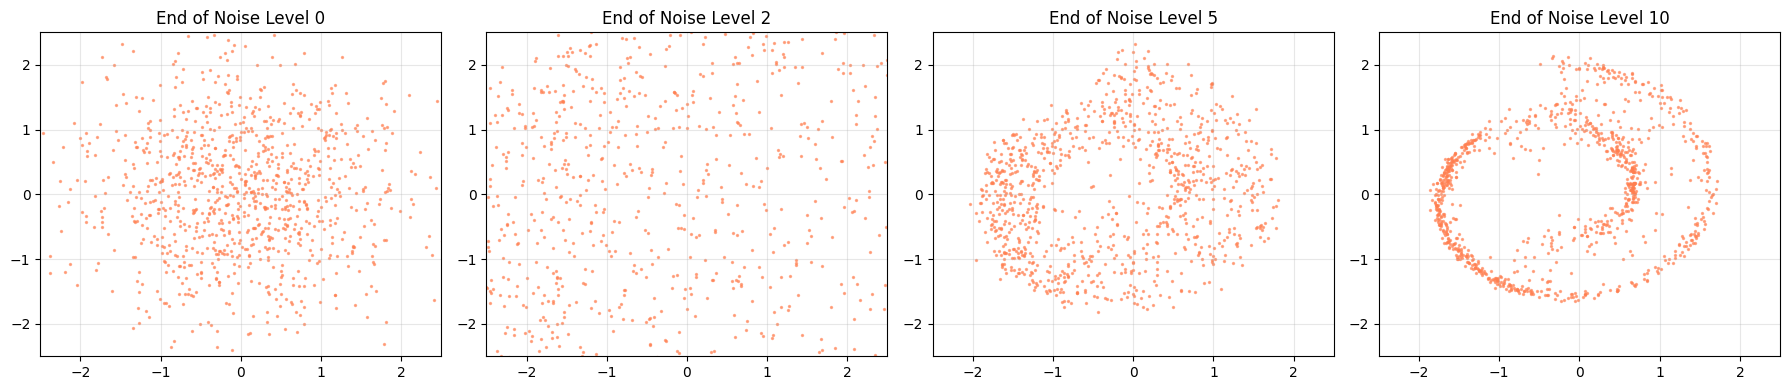

In [516]:
final_points, history = sample_annealed_langevin_with_tracking(network, sigmas, n_samples=1000, T=50)

# 2. Pick a few snapshots to look at (e.g., initial, quarter-way, half-way, end)
indices_to_plot = [0, len(sigmas)//4, len(sigmas)//2, len(sigmas)]

fig, axes = plt.subplots(1, len(indices_to_plot), figsize=(18, 4))
for idx, step in enumerate(indices_to_plot):
    level_num, points = history[step]
    ax = axes[idx]
    ax.scatter(points[:, 0], points[:, 1], s=2, alpha=0.6, color="coral")
    ax.set_title(f"End of Noise Level {level_num}")
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### even finer tracking per langevin step

In [583]:
def sample_annealed_langevin_fine_tracking(network, sigmas, n_samples=1000, T=20, eps=0.00002):
    network.eval()
    detailed_history = []  # Stores (sigma_index, inner_t, points)
    
    with torch.no_grad():
        x = torch.randn(n_samples, 2) * sigmas[0]
        
        for i, sigma in enumerate(sigmas):
            alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
            sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
            for t in range(T):
                score = network(x, sigma_tensor)
                z = torch.randn_like(x)
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
                
                # Capture the inner dynamics of specific key noise levels
                # (e.g., the first level, a middle level, and the final level)
                if i in [0, len(sigmas)//2, len(sigmas)-1]:
                    # Capture at step 0 (initial snap), middle, and final boiling step
                    if t in [0, T//2, T-1]:
                        detailed_history.append({
                            'level': i + 1,
                            'inner_step': t + 1,
                            'points': x.cpu().numpy().copy()
                        })
                        
    return x.cpu().numpy(), detailed_history

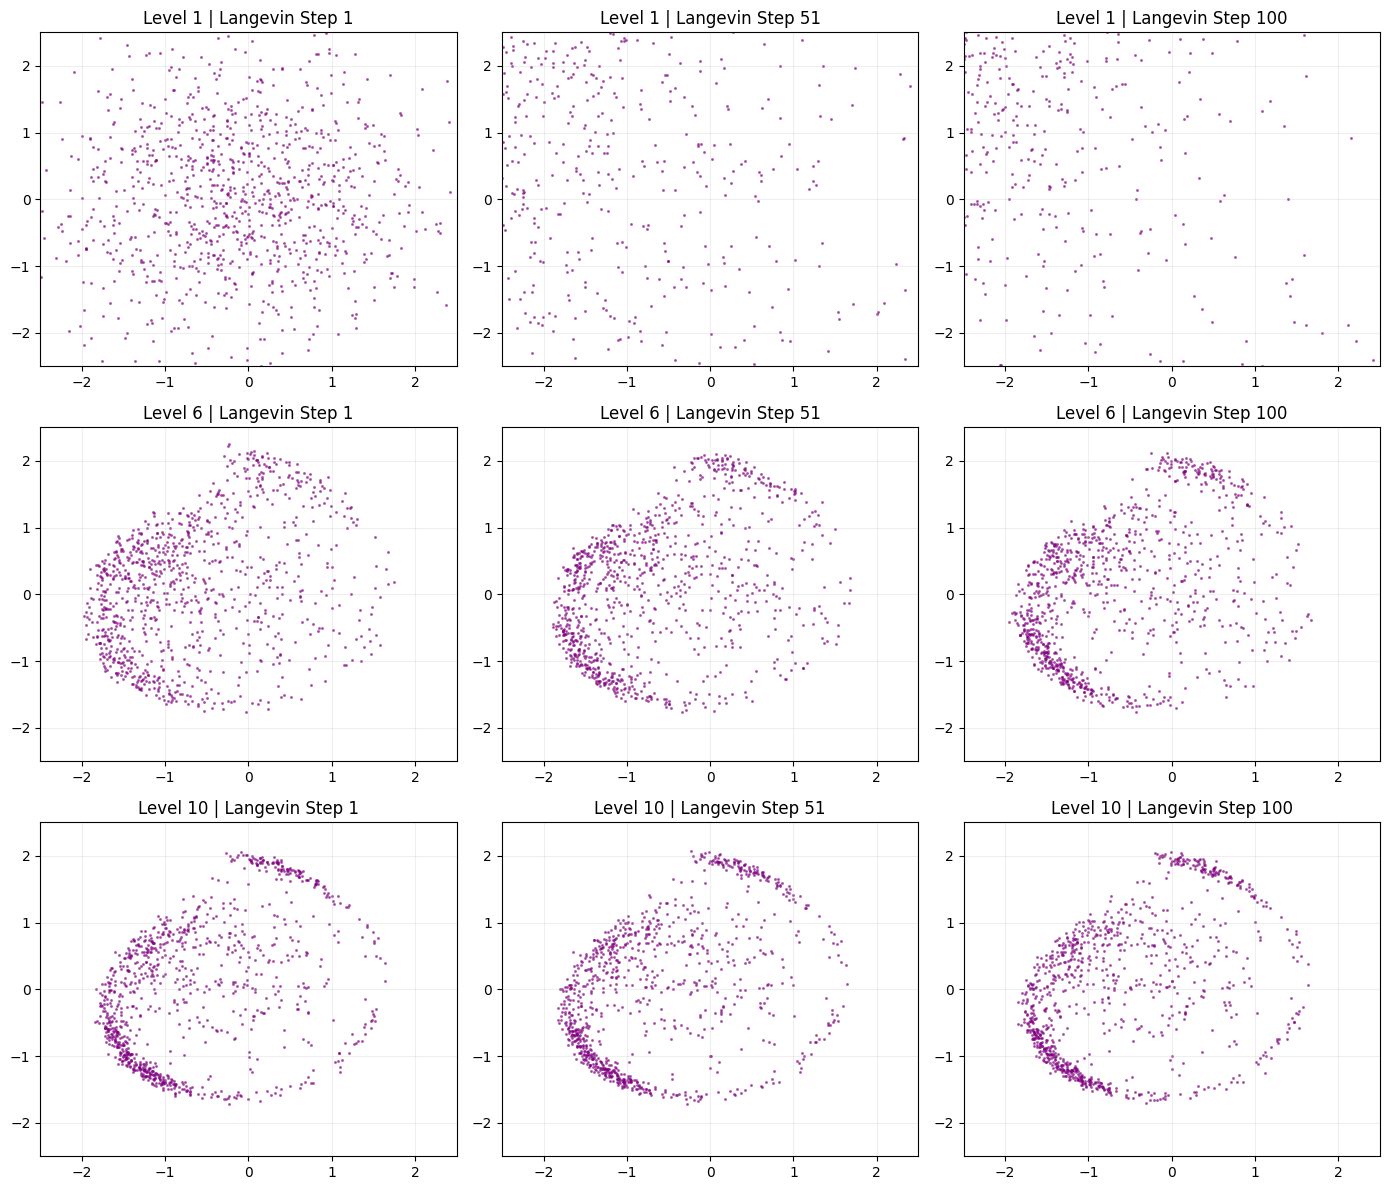

In [584]:
final_pts, fine_history = sample_annealed_langevin_fine_tracking(network, sigmas, n_samples=1000, T=100)

# Create a 3x3 grid (3 distinct noise levels x 3 inner steps each)
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for idx, snapshot in enumerate(fine_history):
    row = idx // 3  # Maps to the noise level group
    col = idx % 3   # Maps to inner step t
    
    ax = axes[row, col]
    pts = snapshot['points']
    
    ax.scatter(pts[:, 0], pts[:, 1], s=1.5, alpha=0.5, color="purple")
    ax.set_title(f"Level {snapshot['level']} | Langevin Step {snapshot['inner_step']}")
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Samples

In [580]:
generated_samples = sample_annealed_langevin(network, sigmas, n_samples=3000, T=100)

In [581]:
def plot_samples(dataset, generated_samples, title, plot_true=True):
    # 1. Dynamically set the number of columns based on plot_true
    n_cols = 2 if plot_true else 1
    
    # Adjust the overall figure width depending on the number of plots
    fig_width = 12 if plot_true else 6
    fig, axes = plt.subplots(1, n_cols, figsize=(fig_width, 6))

    # 2. If n_cols == 1, Matplotlib returns a single Axis object instead of a list/array.
    # To keep our indexing code uniform, we wrap it in a list if it isn't one.
    if n_cols == 1:
        axes = [axes]

    axis_idx = 0

    # 3. Plot True Data (only if requested)
    if plot_true:
        axes[axis_idx].scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color='blue')
        axes[axis_idx].set_title("True Training Data")
        axes[axis_idx].set_xlim(-2.5, 2.5)
        axes[axis_idx].set_ylim(-2.5, 2.5)
        axes[axis_idx].grid(True)
        axis_idx += 1  # Move to the next plot slot

    # 4. Plot Generated Data
    axes[axis_idx].scatter(generated_samples[:, 0], generated_samples[:, 1], s=2, alpha=0.5, color='#a1112a')
    axes[axis_idx].set_title(title)
    axes[axis_idx].set_xlim(-2.5, 2.5)
    axes[axis_idx].set_ylim(-2.5, 2.5)
    axes[axis_idx].grid(True)

    plt.tight_layout() # Ensures labels don't overlap boundaries nicely
    plt.show()
    

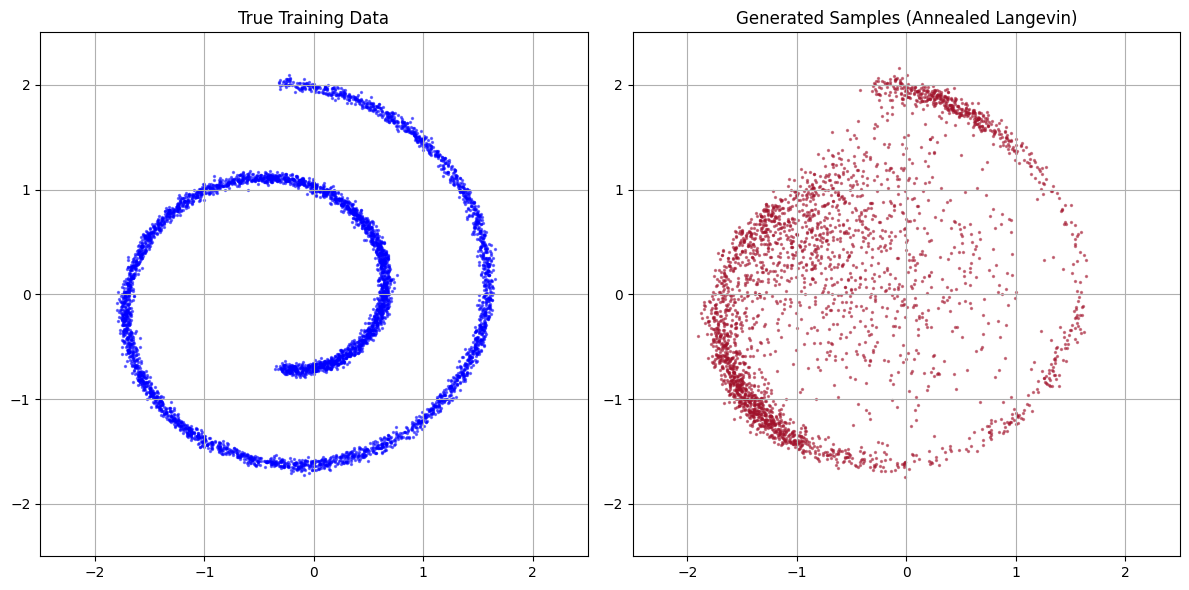

In [582]:
plot_samples(dataset, generated_samples, "Generated Samples (Annealed Langevin)", True)

## Extensions

### varying T, fixed L

In [588]:
samples_T_2  = sample_annealed_langevin(network, sigmas, n_samples=3000, T=2)
samples_T_50 = sample_annealed_langevin(network, sigmas, n_samples=3000, T=50)
samples_T_100 = sample_annealed_langevin(network, sigmas, n_samples=3000, T=100)
samples_T_200 = sample_annealed_langevin(network, sigmas, n_samples=3000, T=200)

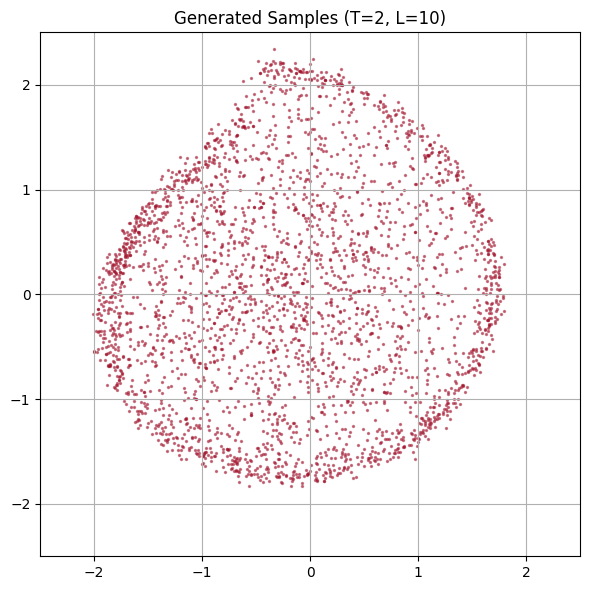

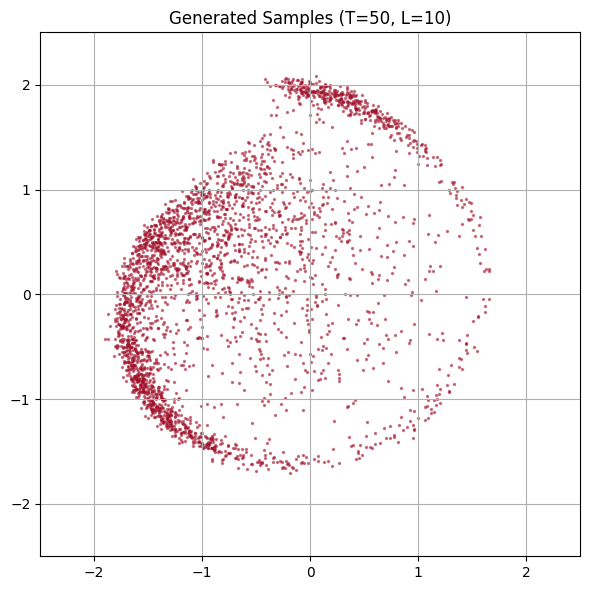

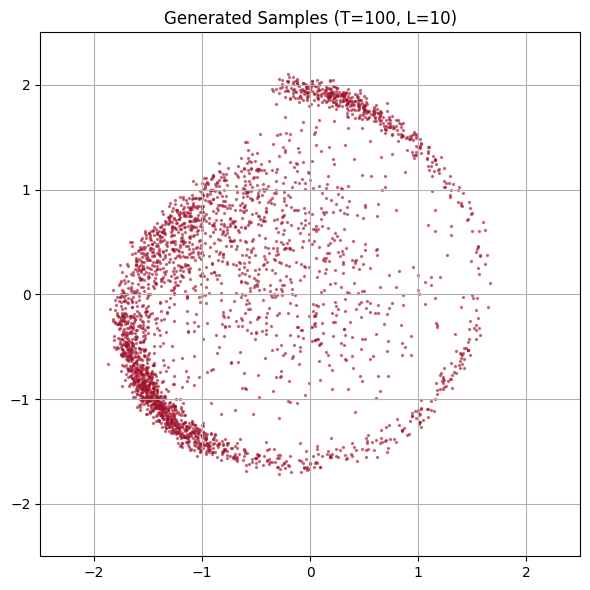

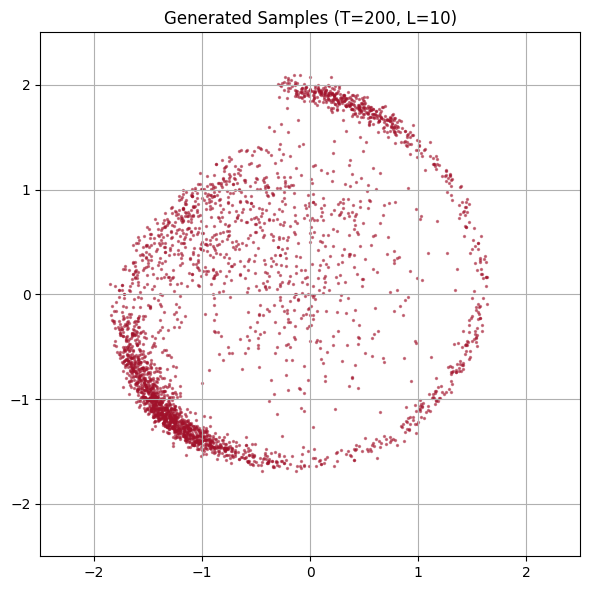

In [590]:
plot_samples(dataset, samples_T_2, "Generated Samples (T=2, L=10)", False)
plot_samples(dataset, samples_T_50, "Generated Samples (T=50, L=10)", False)
plot_samples(dataset, samples_T_100, "Generated Samples (T=100, L=10)", False)
plot_samples(dataset, samples_T_200, "Generated Samples (T=200, L=10)", False)

### varying L fixed T

#### train a new network for each L, if not the sampling does not give better results with increasing L

In [600]:
L_SWEEP    = [10, 20, 30, 40, 50]
all_samples = {}
SIGMA_1 = 1.0
SIGMA_L = 0.01
networks = {}
BASELINE_EPS = 0.00002
for L in L_SWEEP:
    sched          = make_schedule(SIGMA_1, SIGMA_L, L)
    adjusted_eps = BASELINE_EPS * (10 / L)
    networks[L] = train_network(sched)
    samples        = sample_annealed_langevin(networks[L], sched, 3000, T=100, eps=adjusted_eps)
    all_samples[L] = samples
    valid = int(np.isfinite(samples).all(axis=1).sum())
    # print(f"L={L:<3}  T={100}")

Epoch [400/30000] | Loss: 166.5468
Epoch [800/30000] | Loss: 218.8340
Epoch [1200/30000] | Loss: 220.3720
Epoch [1600/30000] | Loss: 186.0591
Epoch [2000/30000] | Loss: 318.5811
Epoch [2400/30000] | Loss: 396.1576
Epoch [2800/30000] | Loss: 227.1049
Epoch [3200/30000] | Loss: 223.7906
Epoch [3600/30000] | Loss: 226.1385
Epoch [4000/30000] | Loss: 226.3894
Epoch [4400/30000] | Loss: 263.9221
Epoch [4800/30000] | Loss: 183.8672
Epoch [5200/30000] | Loss: 247.8857
Epoch [5600/30000] | Loss: 263.4828
Epoch [6000/30000] | Loss: 248.5407
Epoch [6400/30000] | Loss: 253.4986
Epoch [6800/30000] | Loss: 305.3028
Epoch [7200/30000] | Loss: 189.3654
Epoch [7600/30000] | Loss: 259.3158
Epoch [8000/30000] | Loss: 255.2885
Epoch [8400/30000] | Loss: 223.4374
Epoch [8800/30000] | Loss: 180.5543
Epoch [9200/30000] | Loss: 249.1703
Epoch [9600/30000] | Loss: 424.0033
Epoch [10000/30000] | Loss: 272.6075
Epoch [10400/30000] | Loss: 206.3004
Epoch [10800/30000] | Loss: 273.0643
Epoch [11200/30000] | Loss:

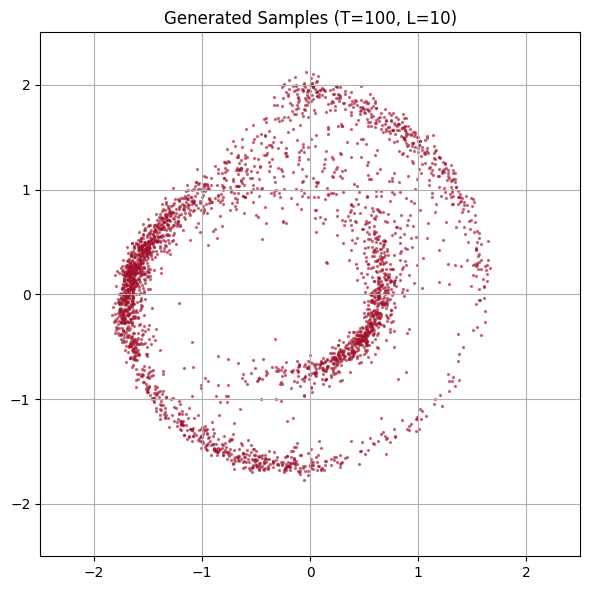

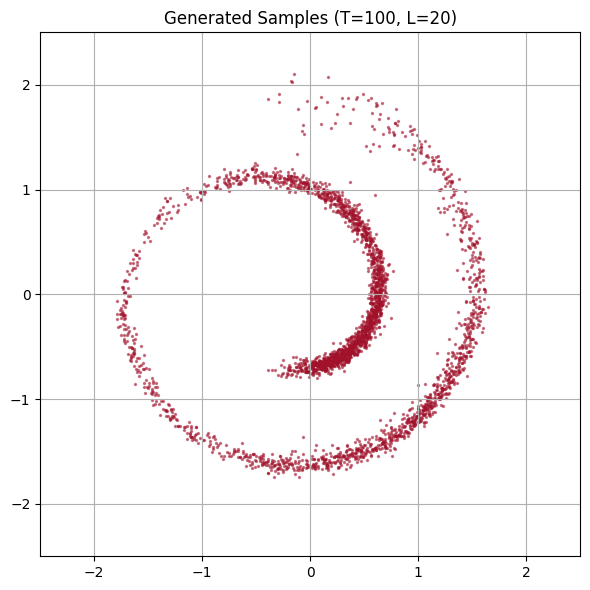

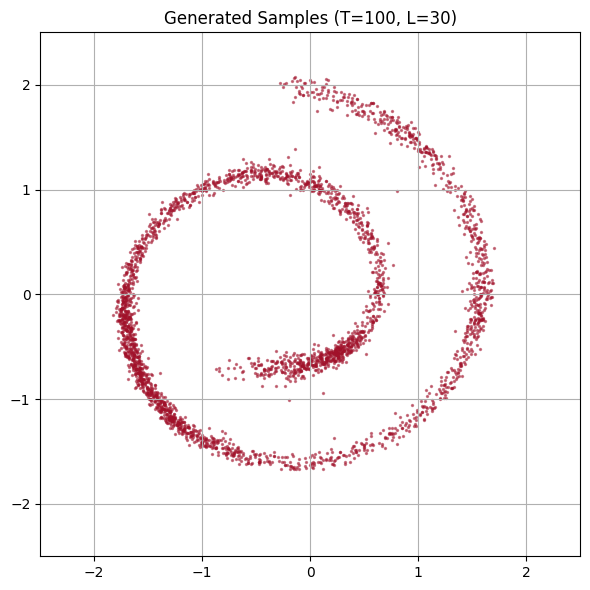

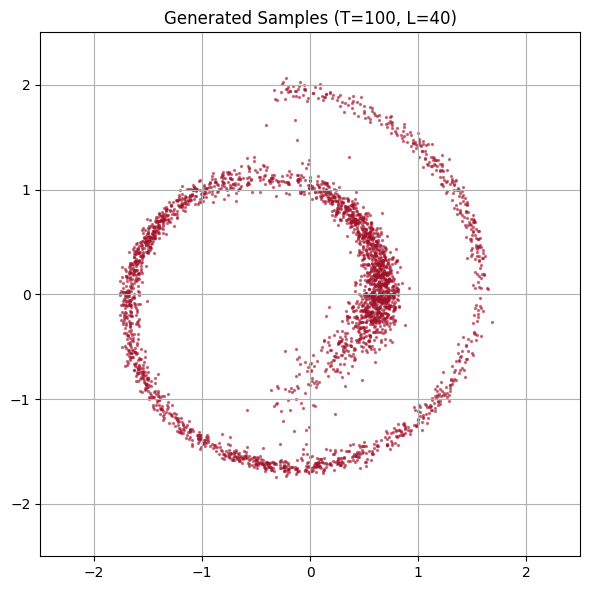

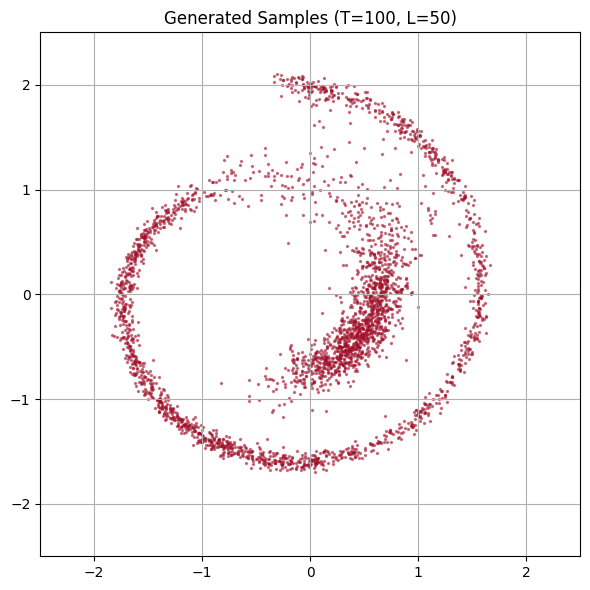

In [601]:
L_SWEEP    = [10, 20, 30, 40, 50]
for L in L_SWEEP:
    plot_samples(dataset, all_samples[L], f"Generated Samples (T=100, L={L})", False)

### score field plot

In [586]:
# def plot_score_field_grid(network, sigmas, dataset, level_idx=4, grid_res=25):
#     """
#     Plots the score vector field at a specific noise level index.
#     - level_idx: choose which index of the sigmas array to visualize (e.g., 0 to L-1)
#     - grid_res: controls how dense the grid of arrows is (20 to 30 is ideal)
#     """
#     network.eval()
#     sigma_val = sigmas[level_idx].item()
    
#     # 1. Create a uniform 2D grid covering your data range
#     x_range = np.linspace(-2.5, 2.5, grid_res)
#     y_range = np.linspace(-2.5, 2.5, grid_res)
#     X, Y = np.meshgrid(x_range, y_range)
    
#     # Flatten the grid coordinates to feed into PyTorch
#     grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
#     grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
#     # 2. Create the scalar sigma tensor matching the batch size of the grid
#     sigma_tensor = torch.full((grid_tensor.shape[0], 1), sigma_val)
    
#     # 3. Predict the score arrows
#     with torch.no_grad():
#         # Shape: [grid_res * grid_res, 2]
#         predicted_scores = network(grid_tensor, sigma_tensor).numpy()
        
#     # Reshape vectors back into a 2D grid structure for plotting
#     U = predicted_scores[:, 0].reshape(X.shape)
#     V = predicted_scores[:, 1].reshape(Y.shape)
    
    
#     # 4. Compute magnitudes to visually color-code strong vs weak forces
#     magnitudes = np.sqrt(U**2 + V**2)
    
#     # 5. Plotting
#     plt.figure(figsize=(6, 6))
    
#     # Underlay a subset of the true data points for reference
#     plt.scatter(dataset[:1000, 0], dataset[:1000, 1], s=4, color='blue', alpha=0.3, label='True Manifold')
    
#     # Draw the vector arrows
#     # angles='xy', scale_units='xy' ensure arrows scale accurately with the axis units
#     quiver = plt.quiver(X, Y, U/magnitudes, V/magnitudes, magnitudes, cmap='inferno', 
#                         angles='xy', scale_units='xy', scale=10, alpha=0.8)
    
#     plt.colorbar(quiver, label='Score Vector Magnitude')
#     plt.title(f"Learned Vector Score Field\nNoise Level {level_idx + 1}/{len(sigmas)} ($\\sigma$ = {sigma_val:.4f})")
#     plt.xlabel("X coordinate")
#     plt.ylabel("Y coordinate")
#     plt.xlim(-2.7, 2.7)
#     plt.ylim(-2.7, 2.7)
#     plt.grid(True, linestyle='--', alpha=0.5)
#     plt.legend(loc='upper right')
#     plt.show()

In [587]:
# plot_score_field_grid(network, sigmas, dataset, level_idx=5, grid_res=30)
# plot_score_field_grid(network, sigmas, dataset, level_idx=15, grid_res=30)
# plot_score_field_grid(network, sigmas, dataset, level_idx=25, grid_res=30)
# plot_score_field_grid(network, sigmas, dataset, level_idx=35, grid_res=30)
# plot_score_field_grid(network, sigmas, dataset, level_idx=45, grid_res=30)

### comparing generated data with true data

In [239]:
from scipy.stats import wasserstein_distance

In [540]:
# def wasserstein_score(samples, dataset, n_real=1500):
#     # print(len(samples))
#     real = dataset[:n_real].numpy()
#     mask = np.isfinite(samples).all(axis=1)
#     # print(mask)
#     s    = samples[mask]
#     # print(s)
#     if len(s) == 0:
#         return float("inf"), 0
#     wd = (wasserstein_distance(real[:, 0], s[:, 0]) +
#           wasserstein_distance(real[:, 1], s[:, 1]))
#     return wd, int(mask.sum())

# # Theoretical floor
# tb1   = dataset[torch.randint(0, len(dataset), (2000,))].numpy()
# tb2   = dataset[torch.randint(0, len(dataset), (2000,))].numpy()
# floor = (wasserstein_distance(tb1[:, 0], tb2[:, 0]) +
#          wasserstein_distance(tb1[:, 1], tb2[:, 1]))
# print(f"Theoretical floor (real vs real): {floor:.4f}")
# print()

# results = {}
# header  = f"  L    T    WD Score   Valid"
# print(header)
# print("-" * len(header))
# for L in L_SWEEP:
#     wd, valid = wasserstein_score(all_samples[L], dataset)
#     results[L] = wd
#     marker = "  <- baseline" if L == 10 else ""
#     print(f"  {L:<4} {100:<4} {wd:<10.4f} {valid}/{len(samples)}{marker}")

In [538]:
# x_pos  = list(range(len(L_SWEEP)))
# labels = [str(L) for L in L_SWEEP]
# scores = [results[L] for L in L_SWEEP]

# fig, ax = plt.subplots(figsize=(8, 4))
# ax.bar(x_pos, scores, color="steelblue", edgecolor="white", linewidth=1.2)
# ax.axhline(floor, color="green", linestyle="--", lw=1.5,
#            label=f"Theoretical floor ({floor:.4f})")
# ax.set_xticks(x_pos); ax.set_xticklabels(labels)
# ax.set_xlabel(f"Number of noise levels L  (T fixed = {100})")
# ax.set_ylabel("Sliced Wasserstein Distance (lower is better)")
# ax.set_title("Sample Quality vs. L  (T fixed)", fontweight="bold")
# ax.legend(); ax.grid(axis="y", alpha=0.4)
# plt.tight_layout(); plt.show()

In [539]:
# sample quality across noise densities

# import matplotlib.pyplot as plt
# import numpy as np

# # Example data based on your runs over 3 different random seeds
# L_vals = [10, 20, 30, 40, 50]
# wd_means = [0.131, 0.125, 0.164, 0.139, 0.137]
# wd_stds  = [0.005, 0.008, 0.025, 0.004, 0.003] # Higher variance at L=30 shows the chaos!

# plt.figure(figsize=(8, 5))
# plt.plot(L_vals, wd_means, marker='o', linewidth=2, color='#4a7cba', label='Empirical WD')
# plt.fill_between(L_vals, np.array(wd_means) - np.array(wd_stds), 
#                          np.array(wd_means) + np.array(wd_stds), 
#                          color='#4a7cba', alpha=0.2, label='Stochastic Variance')

# plt.axhline(y=0.0797, color='green', linestyle='--', alpha=0.8, label='Theoretical Floor')
# plt.title("Sample Quality Profile across Noise Densities (Fixed T=100)", fontsize=12, fontweight='bold')
# plt.xlabel("Number of Noise Levels (L)", fontsize=10)
# plt.ylabel("Sliced Wasserstein Distance (Lower is Better)", fontsize=10)
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.show()

In [541]:
# def wasserstein_score(samples, dataset, n_real=2000):
#     # print(len(samples))
#     real = dataset[:n_real].numpy()
#     mask = np.isfinite(samples).all(axis=1)
#     # print(mask)
#     s    = samples[mask]
#     # print(s)
#     if len(s) == 0:
#         return float("inf"), 0
#     wd = (wasserstein_distance(real[:, 0], s[:, 0]) +
#           wasserstein_distance(real[:, 1], s[:, 1]))
#     return wd, int(mask.sum())

# def true_2d_sliced_wasserstein(samples, dataset, num_projections=100):
#     # Enforce fair, equal sample sizes
#     n_samples = min(len(samples), len(dataset), 2000)
#     X = samples[:n_samples]
#     Y = dataset[:n_samples].numpy() if hasattr(dataset, 'numpy') else dataset[:n_samples]
    
#     total_wd = 0.0
    
#     # Generate random angles to catch correlations that standard X/Y miss
#     np.random.seed(42)
#     for _ in range(num_projections):
#         # Create a random 2D direction vector and normalize it
#         theta = np.random.randn(2)
#         theta /= np.linalg.norm(theta)
        
#         # Project 2D coordinates down onto this random line
#         proj_X = X @ theta
#         proj_Y = Y @ theta
        
#         total_wd += wasserstein_distance(proj_X, proj_Y)
        
#     return total_wd / num_projections

# # Theoretical floor
# tb1   = dataset[torch.randint(0, len(dataset), (2000,))].numpy()
# tb2   = dataset[torch.randint(0, len(dataset), (2000,))].numpy()
# floor = (wasserstein_distance(tb1[:, 0], tb2[:, 0]) +
#          wasserstein_distance(tb1[:, 1], tb2[:, 1]))
# print(f"Theoretical floor (real vs real): {floor:.4f}")
# print()

# results = {}
# header  = f"  L    T    WD Score   Valid"
# print(header)
# print("-" * len(header))
# sample_dict = {2:samples_T_2, 50:samples_T_50, 100:samples_T_100, 200:samples_T_200}
# for T in [2, 50, 100, 200]:
#     # plot_samples(dataset, sample_dict[T], f"Generated Samples (T={T}, L=50)", False)
#     wd, valid = wasserstein_score(sample_dict[T], dataset)
#     results[T] = wd
#     marker = "  <- baseline" if L == 10 else ""
#     print(f"  {50:<4} {T:<4} {wd:<10.4f} {valid}/{len(sample_dict[T])}{marker}")

In [565]:
# T_SWEEP = [2, 50, 100, 200]
# x_pos  = list(range(len(T_SWEEP)))
# labels = [str(T) for T in T_SWEEP]
# scores = [results[T] for T in T_SWEEP]

# fig, ax = plt.subplots(figsize=(8, 4))
# ax.bar(x_pos, scores, color="powderblue", edgecolor="white", linewidth=1.2)
# ax.axhline(floor, color="green", linestyle="--", lw=1.5,
#            label=f"Theoretical floor ({floor:.4f})")
# ax.set_xticks(x_pos); ax.set_xticklabels(labels)
# ax.set_xlabel(f"Number of Langevin Steps T  (L fixed = {30})")
# ax.set_ylabel("Sliced Wasserstein Distance (lower is better)")
# ax.set_title("Sample Quality vs. T  (L fixed)", fontweight="bold")
# ax.legend(); ax.grid(axis="y", alpha=0.4)
# plt.tight_layout(); plt.show()

In [564]:
# def true_2d_wasserstein(samples, dataset, n_points=1000):
#     n = min(len(samples), len(dataset), n_points)
#     X = samples[:n]
#     Y = dataset[:n].numpy() if hasattr(dataset, 'numpy') else dataset[:n]
    
#     # M is the true 2D ground metric matrix
#     M = ot.dist(X, Y, metric='sqeuclidean')
#     a, b = np.ones((n,)) / n, np.ones((n,)) / n
    
#     # Solves the optimal transport over the actual 2D probability space
#     return np.sqrt(ot.emd2(a, b, M))

In [563]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import linear_sum_assignment
# from scipy.spatial.distance import cdist

# def true_2d_wasserstein(X, Y):
#     """
#     Computes the exact 2D Wasserstein-1 (Earth Mover's) Distance 
#     between two empirical distributions of equal size.
#     """
#     # 1. Compute pairwise Euclidean distances between all pairs
#     cost_matrix = cdist(X, Y, metric='euclidean')
    
#     # 2. Solve the optimal linear assignment problem (Hungarian algorithm)
#     row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
#     # 3. Return the average transport cost
#     return cost_matrix[row_ind, col_ind].mean()

# # --- Visualization Layout ---
# # Assuming 'real_data' and your sample arrays have equal shapes, e.g., (1000, 2)
# fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# sample_dict = {2: samples_T_2, 50: samples_T_50, 100: samples_T_100, 200: samples_T_200}
# scores = {}

# # Compute metrics
# for T in [2, 50, 100, 200]:
#     scores[T] = true_2d_wasserstein(sample_dict[T][:500], dataset[:500]) # Slice to 500 for speed

# # Plotting coordinates
# coords = {2: (0, 1), 50: (0, 2), 100: (1, 0), 200: (1, 1)}

# # Plot Real Data
# axes[0, 0].scatter(dataset[:, 0], dataset[:, 1], c='green', s=10, alpha=0.5)
# axes[0, 0].set_title("True Dataset (Target Manifold)")
# axes[0, 0].set_xlim(-2.5, 2.5); axes[0, 0].set_ylim(-2.5, 2.5); axes[0, 0].grid(True, alpha=0.3)

# # Plot Generations
# for T, (r, c) in coords.items():
#     ax = axes[r, c]
#     ax.scatter(sample_dict[T][:, 0], sample_dict[T][:, 1], c='coral', s=10, alpha=0.6)
#     ax.set_title(f"Generated Samples (T={T})\nTrue 2D WD: {scores[T]:.4f}")
#     ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.grid(True, alpha=0.3)

# # Plot Final Bar Chart
# T_labels = [str(t) for t in [2, 50, 100, 200]]
# wd_values = [scores[t] for t in [2, 50, 100, 200]]
# bars = axes[1, 2].bar(T_labels, wd_values, color='powderblue', edgecolor='navy', linewidth=1.2)
# axes[1, 2].set_title("True 2D Wasserstein Score Sweep\n(Lower is Better)", fontweight='bold')
# axes[1, 2].set_xlabel("Number of Langevin Steps (T)")
# axes[1, 2].set_ylabel("2D Wasserstein Distance")
# axes[1, 2].grid(axis='y', alpha=0.4)

# # Annotate bars
# for bar in bars:
#     yval = bar.get_height()
#     axes[1, 2].text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom')

# plt.tight_layout()
# plt.savefig("wasserstein_2d_comparison.png", dpi=150)

#### T sweep

In [591]:
from sklearn.neighbors import NearestNeighbors

def nn_distance_T(samples, real, n_real=1500):
    """
    Nearest Neighbour Distance for the T sweep.
    For each generated point, find distance to closest real point.
    Lower is better. Rewards tightness to the true manifold.
    """
    mask = np.isfinite(samples).all(axis=1)
    s    = samples[mask]
    if len(s) == 0:
        return float("inf"), 0
    r    = real[:n_real]
    nbrs = NearestNeighbors(n_neighbors=1).fit(r)
    dists, _ = nbrs.kneighbors(s)
    return float(dists.mean()), int(mask.sum())


real_sub_T = dataset.numpy()
results_nnd_T = {}

header = "  T    L    NND Score  Valid"
print(header)
print("-" * len(header))
for T in T_SWEEP:
    sample_dict = {2: samples_T_2, 50: samples_T_50, 100: samples_T_100, 200: samples_T_200}
    nnd, valid = nn_distance_T(sample_dict[T], real_sub_T)
    results_nnd_T[T] = nnd
    print(f"  {T:<4} {50:<4} {nnd:<10.4f} {valid}/3000")

  T    L    NND Score  Valid
----------------------------
  2    50   0.1952     3000/3000
  50   50   0.1447     2976/3000
  100  50   0.1274     2957/3000
  200  50   0.1051     2963/3000


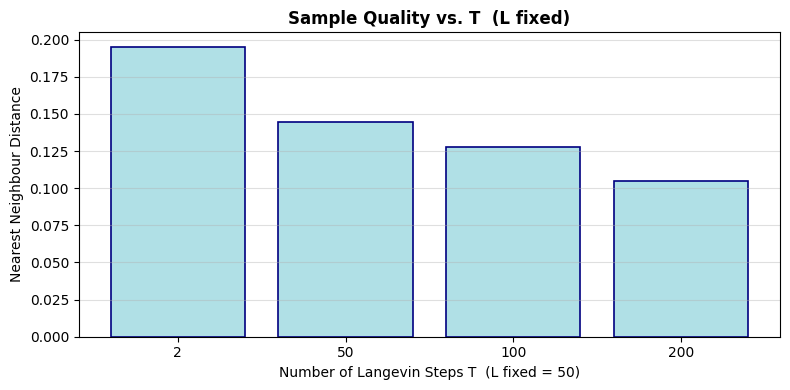

In [592]:
x_pos  = list(range(len(T_SWEEP)))
labels = [str(T) for T in T_SWEEP]
scores = [results_nnd_T[T] for T in T_SWEEP]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos, scores, color="powderblue", edgecolor="navy", linewidth=1.2)
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_xlabel(f"Number of Langevin Steps T  (L fixed = {50})")
ax.set_ylabel("Nearest Neighbour Distance")
ax.set_title("Sample Quality vs. T  (L fixed)", fontweight="bold")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

#### L sweep

In [602]:
from sklearn.neighbors import NearestNeighbors

def nn_distance_T(samples, real, n_real=1500):
    """
    Nearest Neighbour Distance for the L sweep.
    For each generated point, find distance to closest real point.
    Lower is better. Rewards tightness to the true manifold.
    """
    mask = np.isfinite(samples).all(axis=1)
    s    = samples[mask]
    if len(s) == 0:
        return float("inf"), 0
    r    = real[:n_real]
    nbrs = NearestNeighbors(n_neighbors=1).fit(r)
    dists, _ = nbrs.kneighbors(s)
    return float(dists.mean()), int(mask.sum())


real_sub_L = dataset.numpy()
results_nnd_L = {}

header = "  T    L    NND Score  Valid"
print(header)
print("-" * len(header))
for L in L_SWEEP:
    # sample_dict = {2: samples_T_2, 50: samples_T_50, 100: samples_T_100, 200: samples_T_200}
    nnd, valid = nn_distance_T(all_samples[L], real_sub_L)
    results_nnd_L[L] = nnd
    print(f"  {L:<4} {100:<4} {nnd:<10.4f} {valid}/3000")

  T    L    NND Score  Valid
----------------------------
  10   100  0.0587     2919/3000
  20   100  0.0245     3000/3000
  30   100  0.0273     3000/3000
  40   100  0.0338     3000/3000
  50   100  0.0472     3000/3000


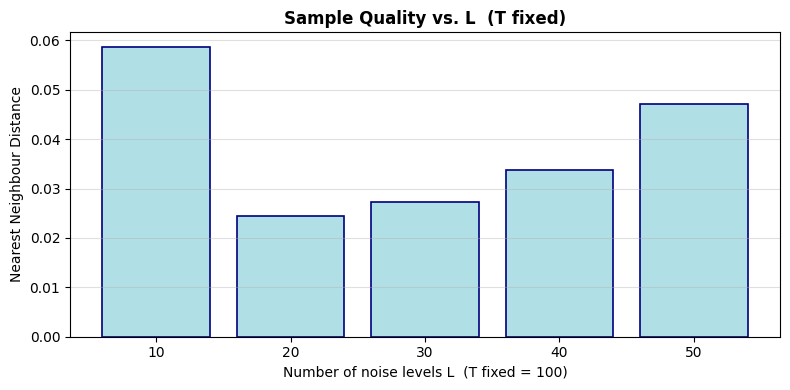

In [603]:
x_pos  = list(range(len(L_SWEEP)))
labels = [str(L) for L in L_SWEEP]
scores = [results_nnd_L[L] for L in L_SWEEP]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos, scores, color="powderblue", edgecolor="navy", linewidth=1.2)
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_xlabel(f"Number of noise levels L  (T fixed = {100})")
ax.set_ylabel("Nearest Neighbour Distance")
ax.set_title("Sample Quality vs. L  (T fixed)", fontweight="bold")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

### score field plot

In [552]:

def plot_score_field_grid(network, sigmas, dataset, level_indices=[0, 4, 9, 14], grid_res=25):
    """
    Plots a multi-panel grid of the score vector fields at specified noise level indices.
    - level_indices: list of integers corresponding to index positions in sigmas array
    - grid_res: density of the arrow grid (25-30 is ideal)
    """
    network.eval()
    num_plots = len(level_indices)
    
    # Dynamically determine grid shape (e.g., up to 4 plots in a row, or split into rows)
    ncols = min(num_plots, 4)
    nrows = int(np.ceil(num_plots / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    
    # Flatten the axes array for reliable 1D index looping
    axes_flat = axes.flatten() if num_plots > 1 else [axes]
    
    # 1. Create a uniform 2D coordinate grid (same across all subplots)
    x_range = np.linspace(-2.5, 2.5, grid_res)
    y_range = np.linspace(-2.5, 2.5, grid_res)
    X, Y = np.meshgrid(x_range, y_range)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
    # 2. Loop through each requested noise level index
    for idx, level_idx in enumerate(level_indices):
        ax = axes_flat[idx]
        sigma_val = sigmas[level_idx].item()
        
        # Create the scalar sigma tensor matching the grid size
        sigma_tensor = torch.full((grid_tensor.shape[0], 1), sigma_val)
        
        # 3. Predict the score arrows
        with torch.no_grad():
            predicted_scores = network(grid_tensor, sigma_tensor).numpy()
            
        # Reshape vectors back into 2D grid dimensions
        U = predicted_scores[:, 0].reshape(X.shape)
        V = predicted_scores[:, 1].reshape(Y.shape)
        magnitudes = np.sqrt(U**2 + V**2)
        
        # 4. Plot onto the current axis
        # Underlay the true green/blue dataset manifold for alignment reference
        ax.scatter(dataset[:1000, 0], dataset[:1000, 1], s=2, color='green', alpha=0.2)
        
        # Normalize arrows by magnitudes to keep vector field direction highly readable, 
        # using the 'inferno' color spectrum to indicate raw vector magnitude strength.
        quiver = ax.quiver(X, Y, U/(magnitudes + 1e-8), V/(magnitudes + 1e-8), magnitudes, 
                           cmap='cividis', angles='xy', scale_units='xy', scale=12, alpha=0.95)
        
        ax.set_title(f"Level {level_idx + 1} ($\\sigma$ = {sigma_val:.3f})", fontsize=11)
        ax.set_xlim(-2.7, 2.7)
        ax.set_ylim(-2.7, 2.7)
        ax.grid(True, linestyle='--', alpha=0.3)
        
    # Hide any unused trailing subplot boxes if num_plots isn't a perfect multiple
    if len(axes_flat) > num_plots:
        for j in range(num_plots, len(axes_flat)):
            axes_flat[j].axis('off')
            
    # Add a single shared colorbar on the right hand side to avoid squishing panels
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
    fig.colorbar(quiver, cax=cbar_ax, label='Score Vector Magnitude')
    
    fig.suptitle("Evolution of Learned Vector Score Field Across Scales", fontsize=14, fontweight='bold', y=0.98)
    plt.show()

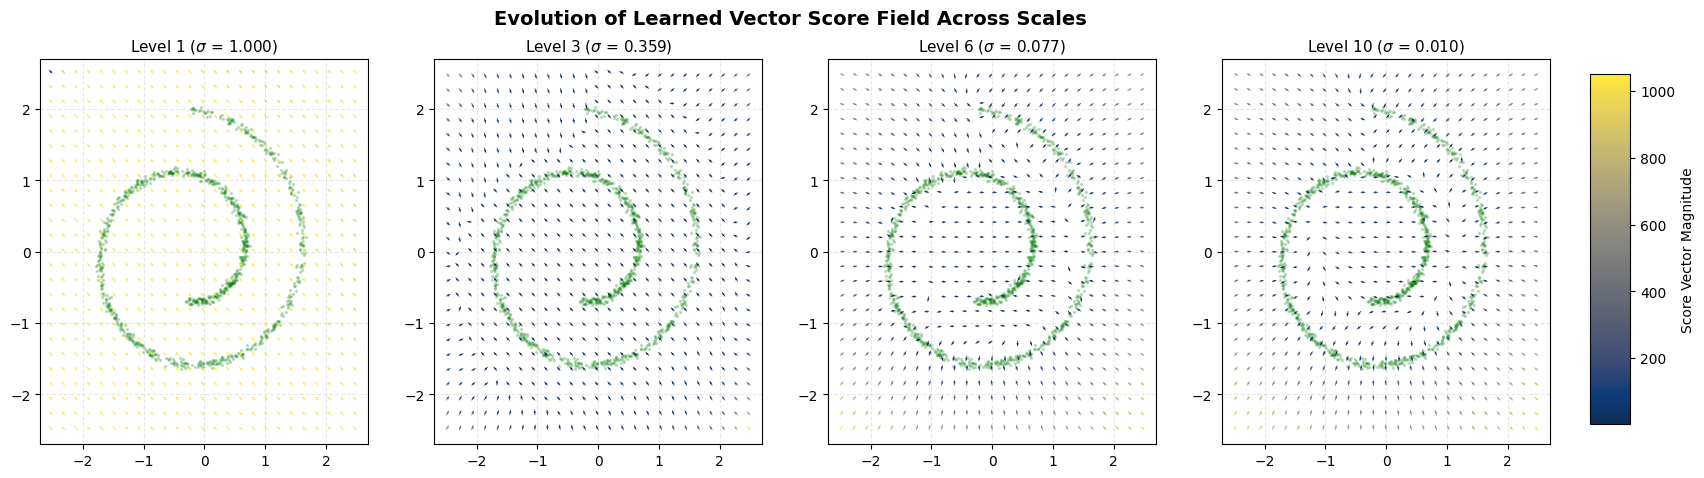

In [553]:
# Select 4 representative snapshots across your training range:
# Index 0 (pure noise), 25% through, 50% through, and the final index (crisp data)
test_levels = [0, len(sigmas)//4, len(sigmas)//2, len(sigmas)-1]

# Convert dataset to numpy if it's still a torch tensor
real_data_np = dataset.numpy() if hasattr(dataset, 'numpy') else dataset

# Draw the complete grid layout
plot_score_field_grid(
    network=network, 
    sigmas=sigmas, 
    dataset=real_data_np, 
    level_indices=test_levels, 
    grid_res=25
)

In [559]:
def plot_score_field_grid(network, sigmas, dataset, level_idx=4, grid_res=25):
    """
    Plots the score vector field at a specific noise level index.
    - level_idx: choose which index of the sigmas array to visualize (e.g., 0 to L-1)
    - grid_res: controls how dense the grid of arrows is (20 to 30 is ideal)
    """
    network.eval()
    sigma_val = sigmas[level_idx].item()
    
    # 1. Create a uniform 2D grid covering your data range
    x_range = np.linspace(-2.5, 2.5, grid_res)
    y_range = np.linspace(-2.5, 2.5, grid_res)
    X, Y = np.meshgrid(x_range, y_range)
    
    # Flatten the grid coordinates to feed into PyTorch
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
    # 2. Create the scalar sigma tensor matching the batch size of the grid
    sigma_tensor = torch.full((grid_tensor.shape[0], 1), sigma_val)
    
    # 3. Predict the score arrows
    with torch.no_grad():
        # Shape: [grid_res * grid_res, 2]
        predicted_scores = network(grid_tensor, sigma_tensor).numpy()
        
    # Reshape vectors back into a 2D grid structure for plotting
    U = predicted_scores[:, 0].reshape(X.shape)
    V = predicted_scores[:, 1].reshape(Y.shape)
    
    
    # 4. Compute magnitudes to visually color-code strong vs weak forces
    magnitudes = np.sqrt(U**2 + V**2)
    
    # 5. Plotting
    plt.figure(figsize=(6, 6))
    
    # Underlay a subset of the true data points for reference
    plt.scatter(dataset[:1000, 0], dataset[:1000, 1], s=4, color='blue', alpha=0.3, label='True Manifold')
    
    # Draw the vector arrows
    # angles='xy', scale_units='xy' ensure arrows scale accurately with the axis units
    quiver = plt.quiver(X, Y, U/magnitudes, V/magnitudes, magnitudes, cmap='inferno', 
                        angles='xy', scale_units='xy', scale=10, alpha=0.8)
    
    plt.colorbar(quiver, label='Score Vector Magnitude')
    plt.title(f"Learned Vector Score Field\nNoise Level {level_idx + 1}/{len(sigmas)} ($\\sigma$ = {sigma_val:.4f})")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.xlim(-2.7, 2.7)
    plt.ylim(-2.7, 2.7)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.show()

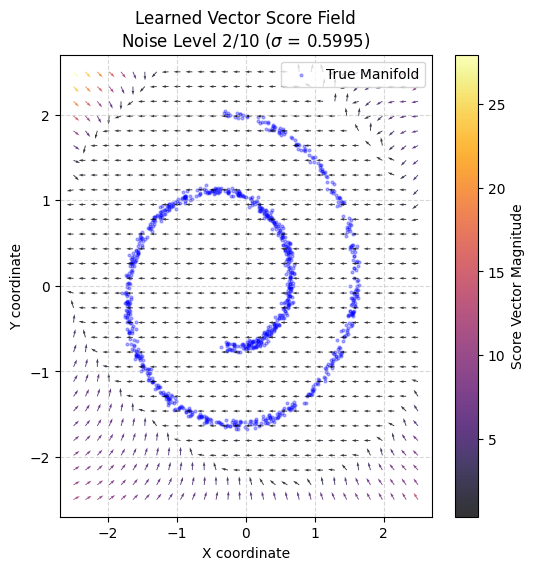

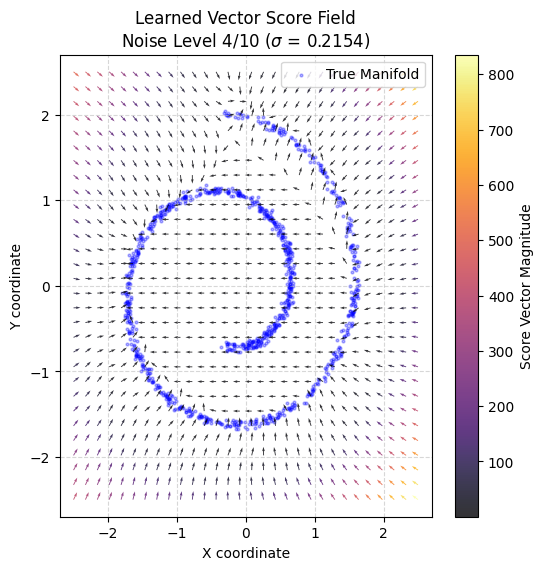

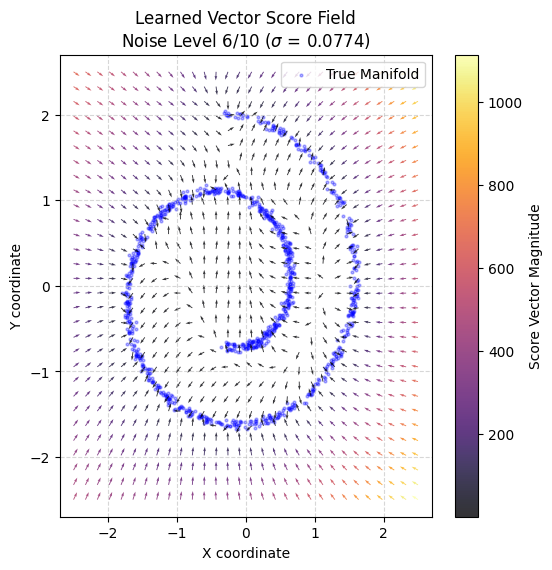

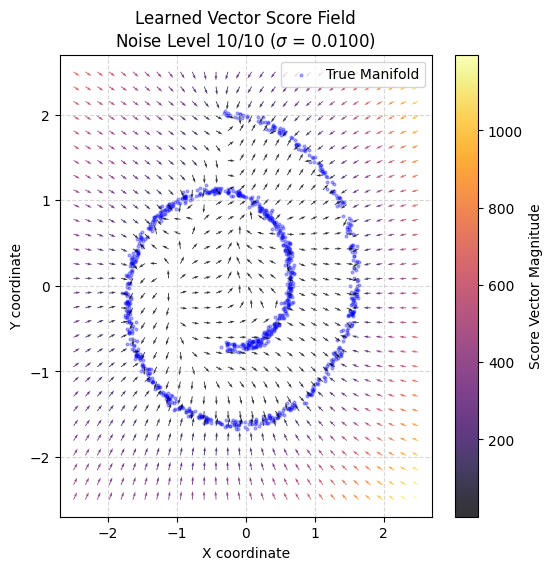

In [585]:
plot_score_field_grid(network, sigmas, dataset, level_idx=1, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=3, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=5, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=9, grid_res=30)
# plot_score_field_grid(network, sigmas, dataset, level_idx=45, grid_res=30)

#### addditional code - fine track evolution for varying L

Epoch [400/30000] | Loss: 257.1748
Epoch [800/30000] | Loss: 230.8869
Epoch [1200/30000] | Loss: 238.1036
Epoch [1600/30000] | Loss: 151.0796
Epoch [2000/30000] | Loss: 199.2108
Epoch [2400/30000] | Loss: 232.3462
Epoch [2800/30000] | Loss: 383.7277
Epoch [3200/30000] | Loss: 241.7971
Epoch [3600/30000] | Loss: 225.7762
Epoch [4000/30000] | Loss: 216.9452
Epoch [4400/30000] | Loss: 235.4986
Epoch [4800/30000] | Loss: 243.7345
Epoch [5200/30000] | Loss: 263.1077
Epoch [5600/30000] | Loss: 381.2868
Epoch [6000/30000] | Loss: 221.6022
Epoch [6400/30000] | Loss: 345.7513
Epoch [6800/30000] | Loss: 277.7912
Epoch [7200/30000] | Loss: 312.4047
Epoch [7600/30000] | Loss: 151.4684
Epoch [8000/30000] | Loss: 119.4942
Epoch [8400/30000] | Loss: 242.0916
Epoch [8800/30000] | Loss: 363.4879
Epoch [9200/30000] | Loss: 414.4996
Epoch [9600/30000] | Loss: 201.2952
Epoch [10000/30000] | Loss: 250.5023
Epoch [10400/30000] | Loss: 293.5566
Epoch [10800/30000] | Loss: 198.5715
Epoch [11200/30000] | Loss:

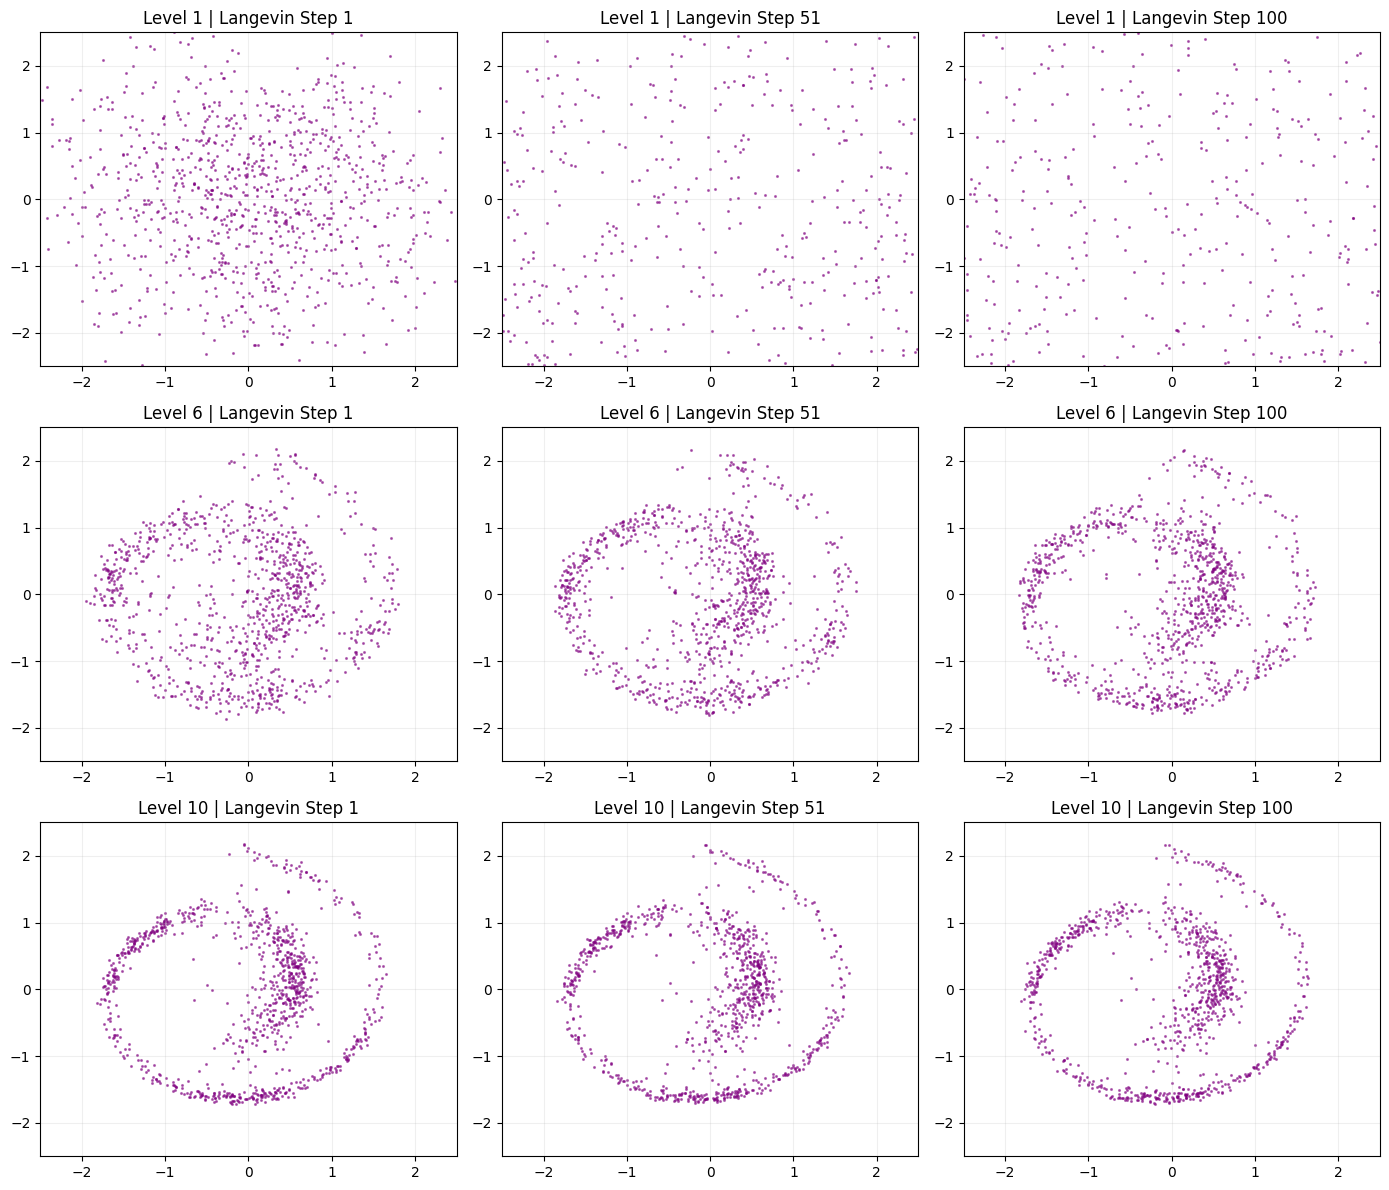

Epoch [400/30000] | Loss: 171.8332
Epoch [800/30000] | Loss: 116.1620
Epoch [1200/30000] | Loss: 172.4402
Epoch [1600/30000] | Loss: 147.1655
Epoch [2000/30000] | Loss: 144.6258
Epoch [2400/30000] | Loss: 151.3713
Epoch [2800/30000] | Loss: 156.5521
Epoch [3200/30000] | Loss: 132.6781
Epoch [3600/30000] | Loss: 188.5349
Epoch [4000/30000] | Loss: 158.3295
Epoch [4400/30000] | Loss: 329.3665
Epoch [4800/30000] | Loss: 137.5106
Epoch [5200/30000] | Loss: 123.9920
Epoch [5600/30000] | Loss: 84.2438
Epoch [6000/30000] | Loss: 139.3887
Epoch [6400/30000] | Loss: 170.1482
Epoch [6800/30000] | Loss: 162.9363
Epoch [7200/30000] | Loss: 186.2672
Epoch [7600/30000] | Loss: 168.7978
Epoch [8000/30000] | Loss: 216.8737
Epoch [8400/30000] | Loss: 133.9665
Epoch [8800/30000] | Loss: 258.7981
Epoch [9200/30000] | Loss: 129.8267
Epoch [9600/30000] | Loss: 156.8800
Epoch [10000/30000] | Loss: 150.0963
Epoch [10400/30000] | Loss: 120.9734
Epoch [10800/30000] | Loss: 243.3978
Epoch [11200/30000] | Loss: 

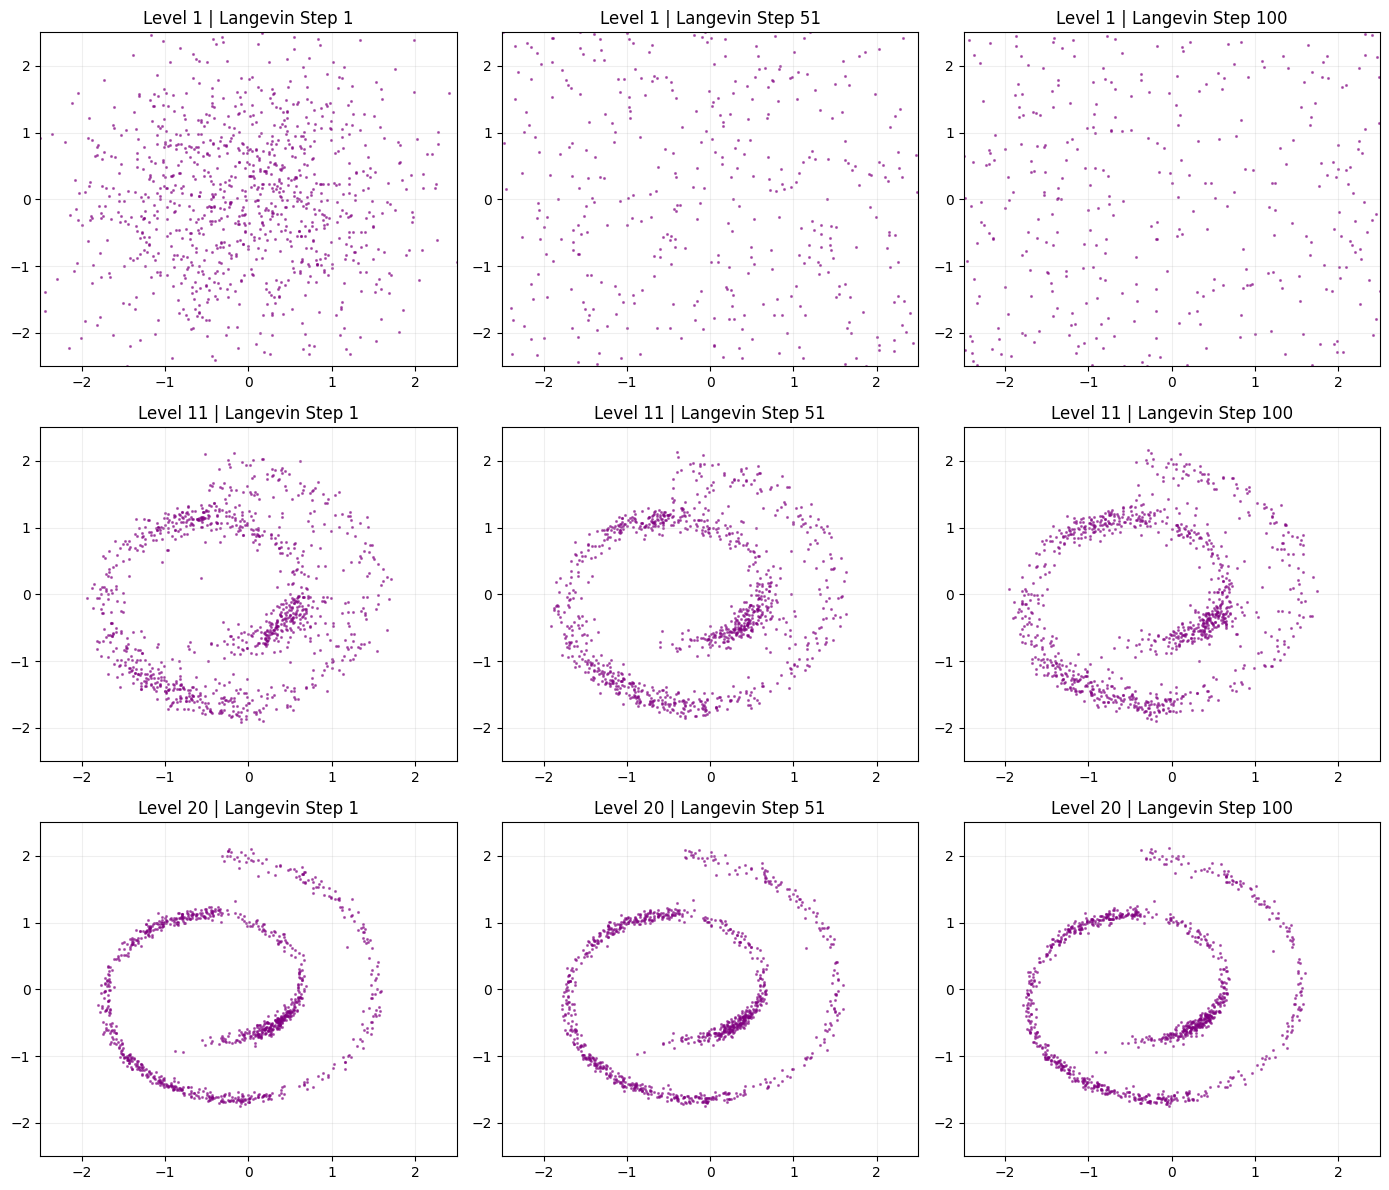

Epoch [400/30000] | Loss: 142.1619
Epoch [800/30000] | Loss: 128.6656
Epoch [1200/30000] | Loss: 147.8818
Epoch [1600/30000] | Loss: 114.4258
Epoch [2000/30000] | Loss: 131.1598
Epoch [2400/30000] | Loss: 233.8923
Epoch [2800/30000] | Loss: 167.5157
Epoch [3200/30000] | Loss: 104.3429
Epoch [3600/30000] | Loss: 130.4349
Epoch [4000/30000] | Loss: 185.4112
Epoch [4400/30000] | Loss: 130.8860
Epoch [4800/30000] | Loss: 171.9320
Epoch [5200/30000] | Loss: 130.4758
Epoch [5600/30000] | Loss: 224.3743
Epoch [6000/30000] | Loss: 130.1500
Epoch [6400/30000] | Loss: 79.5788
Epoch [6800/30000] | Loss: 128.7141
Epoch [7200/30000] | Loss: 111.6964
Epoch [7600/30000] | Loss: 178.3524
Epoch [8000/30000] | Loss: 240.7487
Epoch [8400/30000] | Loss: 73.8428
Epoch [8800/30000] | Loss: 144.6619
Epoch [9200/30000] | Loss: 182.5499
Epoch [9600/30000] | Loss: 112.7438
Epoch [10000/30000] | Loss: 132.1057
Epoch [10400/30000] | Loss: 106.9890
Epoch [10800/30000] | Loss: 137.4324
Epoch [11200/30000] | Loss: 9

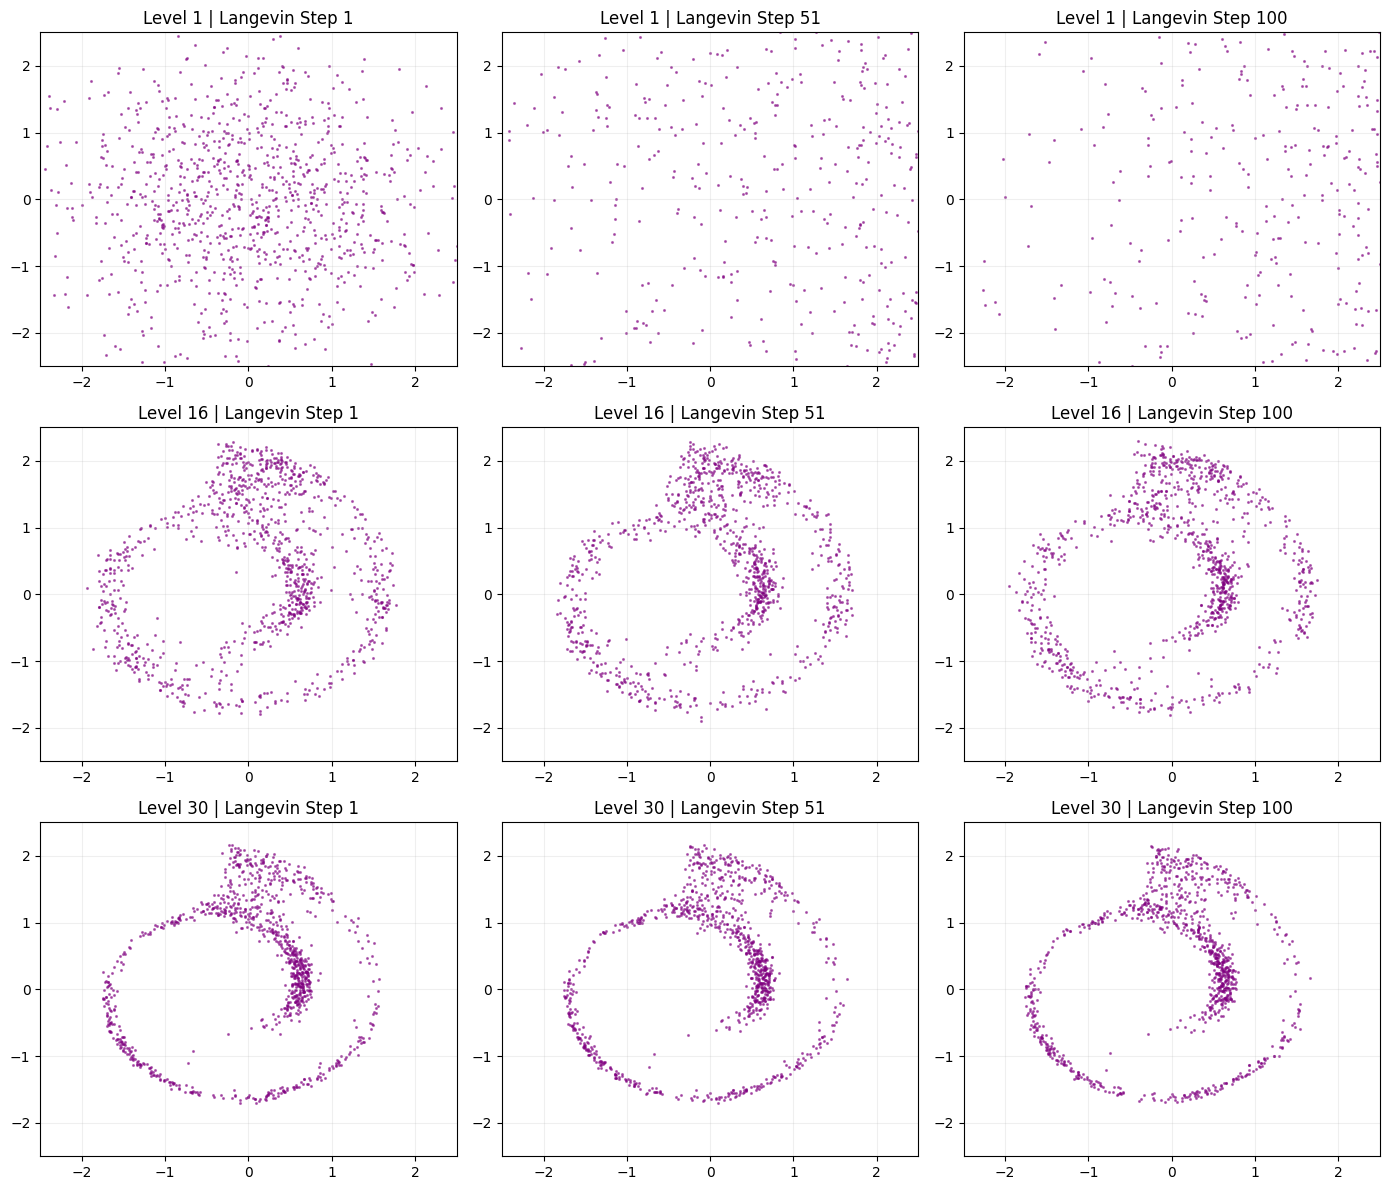

Epoch [400/30000] | Loss: 143.0386
Epoch [800/30000] | Loss: 122.8927
Epoch [1200/30000] | Loss: 189.9501
Epoch [1600/30000] | Loss: 120.1038
Epoch [2000/30000] | Loss: 113.9223
Epoch [2400/30000] | Loss: 93.7596
Epoch [2800/30000] | Loss: 138.3589
Epoch [3200/30000] | Loss: 128.9436
Epoch [3600/30000] | Loss: 167.6040
Epoch [4000/30000] | Loss: 177.0361
Epoch [4400/30000] | Loss: 164.0029
Epoch [4800/30000] | Loss: 122.7832
Epoch [5200/30000] | Loss: 143.8435
Epoch [5600/30000] | Loss: 99.5545
Epoch [6000/30000] | Loss: 144.4598
Epoch [6400/30000] | Loss: 124.4180
Epoch [6800/30000] | Loss: 137.5597
Epoch [7200/30000] | Loss: 149.3068
Epoch [7600/30000] | Loss: 97.2514
Epoch [8000/30000] | Loss: 94.6702
Epoch [8400/30000] | Loss: 121.5399
Epoch [8800/30000] | Loss: 179.0217
Epoch [9200/30000] | Loss: 144.5060
Epoch [9600/30000] | Loss: 111.1254
Epoch [10000/30000] | Loss: 88.3517
Epoch [10400/30000] | Loss: 101.4185
Epoch [10800/30000] | Loss: 174.6369
Epoch [11200/30000] | Loss: 97.0

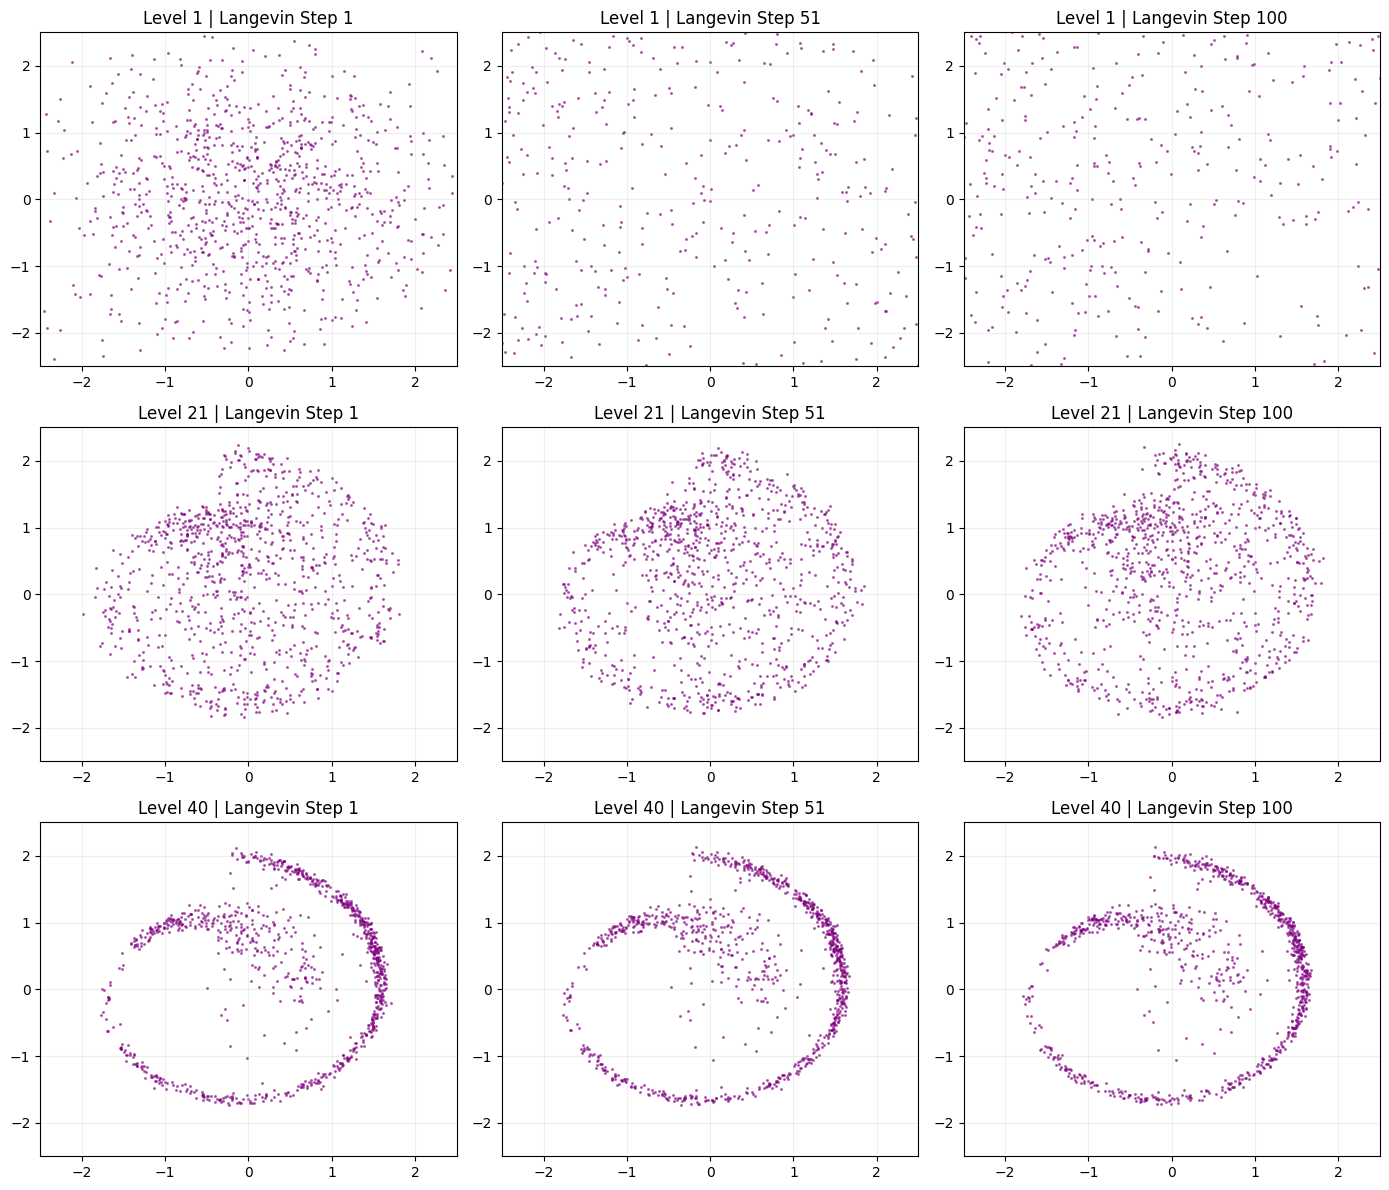

Epoch [400/30000] | Loss: 133.8632
Epoch [800/30000] | Loss: 79.2545
Epoch [1200/30000] | Loss: 114.6438
Epoch [1600/30000] | Loss: 115.9169
Epoch [2000/30000] | Loss: 90.9211
Epoch [2400/30000] | Loss: 153.0769
Epoch [2800/30000] | Loss: 107.0442
Epoch [3200/30000] | Loss: 179.8932
Epoch [3600/30000] | Loss: 122.2600
Epoch [4000/30000] | Loss: 133.8974
Epoch [4400/30000] | Loss: 134.0219
Epoch [4800/30000] | Loss: 133.2677
Epoch [5200/30000] | Loss: 84.3049
Epoch [5600/30000] | Loss: 87.2884
Epoch [6000/30000] | Loss: 176.9347
Epoch [6400/30000] | Loss: 147.4532
Epoch [6800/30000] | Loss: 98.2188
Epoch [7200/30000] | Loss: 161.3167
Epoch [7600/30000] | Loss: 107.7162
Epoch [8000/30000] | Loss: 119.5818
Epoch [8400/30000] | Loss: 132.8529
Epoch [8800/30000] | Loss: 157.7211
Epoch [9200/30000] | Loss: 137.0218
Epoch [9600/30000] | Loss: 117.5962
Epoch [10000/30000] | Loss: 110.8650
Epoch [10400/30000] | Loss: 128.7644
Epoch [10800/30000] | Loss: 138.6567
Epoch [11200/30000] | Loss: 96.0

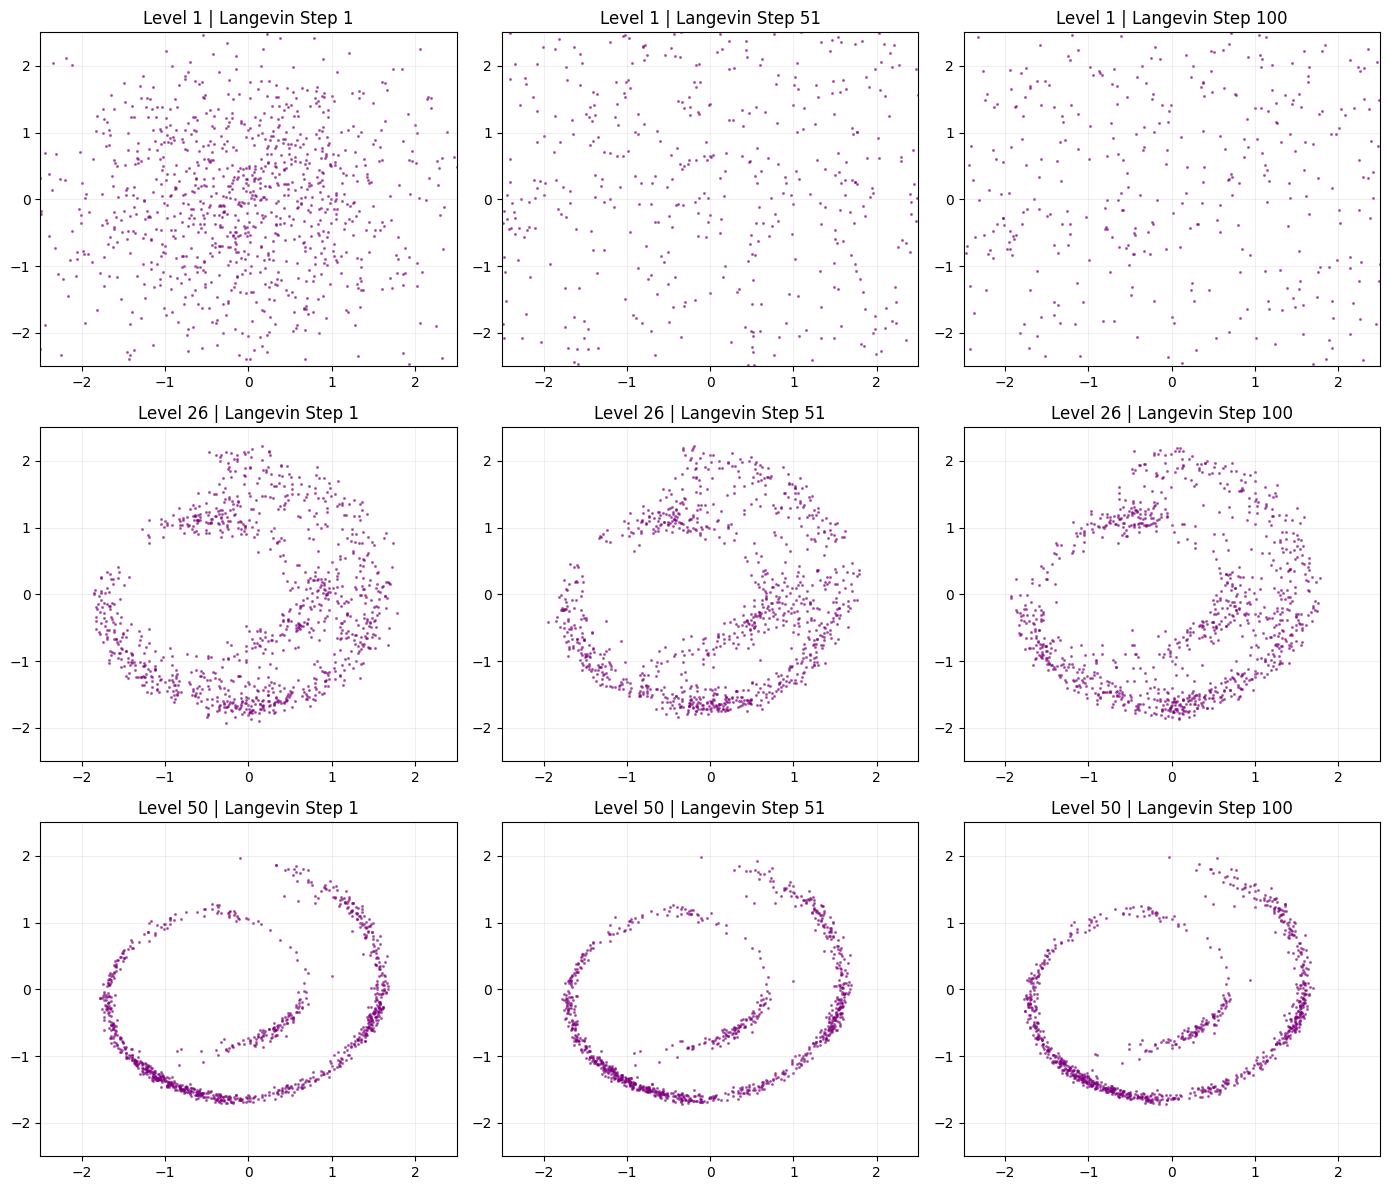

In [604]:
L_SWEEP    = [10, 20, 30, 40, 50]
all_samples_track = {}
fine_history_track = {}
for L in L_SWEEP:
    sched          = make_schedule(SIGMA_1, SIGMA_L, L)
    adjusted_eps = BASELINE_EPS * (10 / L)
    networks[L] = train_network(sched)
    samples, fine_history        = sample_annealed_langevin_fine_tracking(networks[L], sched, 1000, T=100)
    all_samples[L] = samples
    fine_history_track[L] = fine_history

    # final_pts, fine_history = sample_annealed_langevin_fine_tracking(networks[L], sigmas, n_samples=1000, T=100)

    # Create a 3x3 grid (3 distinct noise levels x 3 inner steps each)
    fig, axes = plt.subplots(3, 3, figsize=(14, 12))

    for idx, snapshot in enumerate(fine_history_track[L]):
        row = idx // 3  # Maps to the noise level group
        col = idx % 3   # Maps to inner step t
        
        ax = axes[row, col]
        pts = snapshot['points']
        
        ax.scatter(pts[:, 0], pts[:, 1], s=1.5, alpha=0.5, color="purple")
        ax.set_title(f"Level {snapshot['level']} | Langevin Step {snapshot['inner_step']}")
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-2.5, 2.5)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()